---
title: Solving LinkedIn Tango by Linear Optimization
date: 2025-03-08
---

![Tango Banner](../assets/2-tango/banner.jpg)

Following the same approach as when I solved the [Queens](./1-queens.ipynb) game using LO, I also decided to apply what I learned in Operations Research to solve Tango, another LinkedIn minigame, as part of a strategy to increase user engagement.

---

# How to Play Tango

:::{figure} ../assets/2-tango/example.mp4
:label: tango-example
:alt: A Tango Example
:align: center
:width: 50%
Example of a Tango minigame board. _Source: [LinkedIn](https://www.linkedin.com/games/tango/)_
:::

Objective
: Fill all the squares on the board with moons 🌙 and suns ☀️.

Rules
: The number of moons and suns in each row and column must be the same
: There cannot be more than 2 moons or 2 suns in a row, either in a row or column
: squares separated by the `=` sign must contain the same symbol
: squares separated by the `×` sign must contain opposite symbols

---

# Problem Modeling

To formulate our LOP, it will again be necessary to define the following elements:

- **Ranges**
- **Sets**
- **Decision variables**
- **Parameters**
- **Objective function**
- **Constraints**

## Ranges

$I = \{1, \cdots, n\}$
: The row range, where $n$ is the total number of rows in the grid

$J = \{1, \cdots, m\}$
: The column range, where $n$ is the total number of columns in the grid

## Sets

In the case of the Tango game, in addition to the row and column ranges, it will be necessary to consider the sets of pairs of squares with `=` and `×` signs, in addition to the set of squares already filled with a sun or moon symbol. Therefore, there will be:

$H = I \times J = \{(i, j) \mid \forall i \in I, \forall j \in J\}$
: Set of all board squares $(i, j)$, which is simply the Cartesian product of the ranges $I$ and $J$.

$L = \{(v, w) \mid v, w \in H, v \ne w\}$
: Set of pairs of squares separated by `=`.

$O = \{(v, w) \mid v, w \in H, v \ne w\}$
: Set of pairs of squares separated by `×`.

$K \subset H$
: Set of squares with an already filled symbol.

## Decision Variables

As it was the case with the Queens game, the decision variables here will be binary, since Tango only uses two symbols. Because of this, the LOP is a **BLOP**. Thus, it was agreed that:

$x_{ij} \in \{0,1\}, \forall (i,j) \in H$
: $x_{ij} = 1$, if the square in row $i$ and column $j$ will be filled with a 🌙
: $x_{ij} = 0$, if the same square will be filled with a ☀️

## Parameters

Parameters, unlike the decision variables, are constant values that represent fixed or known values that don't change while the optimization process is running. In case of the Tango, there may be some cells that already come with a predefined symbol: sun or moon. As the set of parameters in our model, there will be:

$k_{ij} \in \{0,1\}, \forall (i,j) \in K$
: $k_{ij} = 1$, if the square in row $i$ and column $j$ is already filled with a 🌙
: $k_{ij} = 0$, if the same square is already filled with a ☀️

## Objective Function

Again, as in the case of Queens, our objective is not to optimize a function, but rather to find a solution that fulfills all the rules of the game. Therefore, the Tango PPLB is not an optimization problem, but a **feasibility problem**. Thus, the objective function will be to maximize (or minimize) an arbitrary constant $C$.

$$\text{Max} \ C$$

## Constraints

With the previous elements well defined, we can translate the rules of the game to our BLOP as follows:

Binarity Constraints
: First, we must define that all decision variables in our problem are binary variables, that is, they only accept 0 and 1 as the only possible values.
: $$x_{ij} \in \{0,1\}, \forall (i,j) \in H$$

Equal-Moons-Suns-Per-Row Constraints
: Since the number of suns and moons for each row must be equal, the sum of $x_{ij}$ belonging to a row $i$ must equal the half of total columns, therefore 3. Since there are 6 rows, the model will have 6 of these constraints.
: $$\sum_{j=1}^{m}{x_{ij}}=\frac{m}{2}, \forall i \in I$$

Equal-Moons-Suns-Per-Column Constraints
: The same logic applies to the columns. Therefore, there are 6 more constraints.
: $$\sum_{i=1}^{n}{x_{ij}}=\frac{n}{2}, \forall j \in J$$

No-Three-Consecutive-Moons-Per-Row Constraints
: Since the 3 moons in a row cannot be next to each other, it means that the sum of three consecutive $x_{ij}$ in a row must be less than or equal to 2.
: $$x_{ij} + x_{i,j+1} + x_{i,j+2} \le 2, \forall i \in I, \forall j \in \{1, \cdots, m-2\}$$

No-Three-Consecutive-Moons-Per-Column Constraints
: And the same logic applies to the columns.
: $$x_{ij} + x_{i+1,j} + x_{i+2,j} \le 2, \forall i \in \{1, \cdots, n-2\}, \forall j \in J$$

No-Three-Consecutive-Suns-Per-Row Constraints
: Similarly, since there cannot be 3 consecutive suns in a row, the sum of 3 subsequent $x_{ij}$ in a row i must be greater than or equal to 1.
: $$x_{ij} + x_{i,j+1} + x_{i,j+2} \ge 1, \forall i \in I, \forall j \in \{1, \cdots,m-2\}$$

No-Three-Consecutive-Suns-Per-Column Constraints
: And the same logic applies to the columns.
: $$x_{ij} + x_{i+1,j} + x_{i+2,j} \ge 1, \forall i \in \{1, \cdots, n-2\}, \forall j \in J$$

Already-Filled-squares Constraints
: For each square that already has a pre-established figure, it is necessary to impose that $x_{ij}$ is equal to 1 or 0, depending on whether the figure is a moon or a sun, respectively.
: $$x_{ij} = k_{ij}, \forall k_{ij} \in K$$

Like-Pairs Constraints
: For each pair of adjacent cells that contains the `=` sign between them, it is necessary to impose the constraint that the values $x_{ij}$ of that pair are equal, which is the same as saying that the difference between the values $x_{ij}$ of that pair must be equal to 0.
: $$x_v - x_w = 0, \forall \{v,w\} \in N$$

Opposite-Pairs Constraints
: Finally, for each pair of adjacent cells that contains the sign `×` between them, it is necessary to impose the constraint that the values $x_{ij}$ of this pair are different, which is the same as saying that the sum of the values $x_{ij}$ of this pair must be equal to 1.
: $$x_v + x_w = 1, \forall \{v,w\} \in M$$

---

# Abstract Model

Up to this point, the formulas created have been based on the premise that every Tango minigame will have 6 rows and 6 columns, which is indeed the case. However, in order to create a more generalized abstract model, we can admit that this will not always be a certainty, and therefore there is a possibility that the number of rows and columns will vary from game to game. Due to the restriction that the number of moons and suns for each row and column must be equal, it must be assumed that the total number of rows and columns are even numbers, that is, $n \mod 2 \equiv 0$ and $m \mod 2 \equiv 0$.

Thus, having raised these points, the abstract model of the Tango minigame is formulated as follows:

$$
\begin{array}{lll}
    & \text{Max} \ C \\
    \text{S.t.:} & \\
    & \sum_{j \in J}{x_{ij}} = m/2,         & \forall i \in I \\
    & \sum_{i \in I}{x_{ij}} = n/2,         & \forall j \in J \\
    & x_{ij} + x_{ij+1} + x_{ij+2} \le 2,   & \forall i \in I, \forall j \in J \backslash \{m-1,m\} \\
    & x_{ij} + x_{i+1,j} + x_{i+2,j} \le 2, & \forall i \in I \backslash \{n-1,n\}, \forall j \in J \\
    & x_{ij} + x_{ij+1} + x_{ij+2} \ge 1,   & \forall i \in I, \forall j \in J \backslash \{m-1,m\} \\
    & x_{ij} + x_{i+1,j} + x_{i+2,j} \ge 1, & \forall i \in I \backslash \{n-1,n\}, \forall j \in J \\
    & x_{ij} = k_{ij},                      & \forall k_{ij} \in K \\
    & x_{ij} - x_{rs} = 0,                  & \forall ((i,j),(r,s)) \in N \\
    & x_{ij} + x_{rs} = 1,                  & \forall ((i,j),(r,s)) \in M \\
    & x_{ij} \in \{0,1\},                   & \forall (i,j) \in H
\end{array}
$$

---

# Concrete Model

The concrete model was built based on the Tango minigame No. 151

:::{figure} ../assets/2-tango/problem.png
:label: tango-problem
:alt: Tango No. 151
:align: center
:width: 50%
Tango No. 151, March 7th, 2025. _Source: [LinkedIn](https://www.linkedin.com/games/tango/)_
:::

:::{math}
:enumerated: false
\text{Max} \ 0
:::

S.t.:

Equal-Moons-Suns-Per-Row Constraints
: $x_{11} + x_{12} + x_{13} + x_{14} + x_{15} + x_{16} = 3$ {sub}`(_Row 1_)`
: $x_{21} + x_{22} + x_{23} + x_{24} + x_{25} + x_{26} = 3$ {sub}`(_Row 2_)`
: $x_{31} + x_{32} + x_{33} + x_{34} + x_{35} + x_{36} = 3$ {sub}`(_Row 3_)`
: $x_{41} + x_{42} + x_{43} + x_{44} + x_{45} + x_{46} = 3$ {sub}`(_Row 4_)`
: $x_{51} + x_{52} + x_{53} + x_{54} + x_{55} + x_{56} = 3$ {sub}`(_Row 5_)`
: $x_{61} + x_{62} + x_{63} + x_{64} + x_{65} + x_{66} = 3$ {sub}`(_Row 6_)`

Equal-Moons-Suns-Per-Column Constraints
: $x_{11} + x_{21} + x_{31} + x_{41} + x_{51} + x_{61} = 3$ {sub}`(_Column 1_)`
: $x_{12} + x_{22} + x_{32} + x_{42} + x_{52} + x_{62} = 3$ {sub}`(_Column 2_)`
: $x_{13} + x_{23} + x_{33} + x_{43} + x_{53} + x_{63} = 3$ {sub}`(_Column 3_)`
: $x_{14} + x_{24} + x_{34} + x_{44} + x_{54} + x_{64} = 3$ {sub}`(_Column 4_)`
: $x_{15} + x_{25} + x_{35} + x_{45} + x_{55} + x_{65} = 3$ {sub}`(_Column 5_)`
: $x_{16} + x_{26} + x_{36} + x_{46} + x_{56} + x_{66} = 3$ {sub}`(_Column 6_)`

No-Three-Consecutive-Moons-Per-Row Constraints
: $x_{11} + x_{21} + x_{31} \le 2$ {sub}`(_Row 1_)`
: $x_{12} + x_{13} + x_{14} \le 2$ {sub}`(_Row 1_)`
: $x_{13} + x_{14} + x_{15} \le 2$ {sub}`(_Row 1_)`
: $x_{14} + x_{15} + x_{16} \le 2$ {sub}`(_Row 1_)`
: $x_{21} + x_{22} + x_{23} \le 2$ {sub}`(_Row 2_)`
: $x_{22} + x_{23} + x_{24} \le 2$ {sub}`(_Row 2_)`
: $x_{23} + x_{24} + x_{25} \le 2$ {sub}`(_Row 2_)`
: $x_{24} + x_{25} + x_{26} \le 2$ {sub}`(_Row 2_)`
: $x_{31} + x_{32} + x_{33} \le 2$ {sub}`(_Row 3_)`
: $x_{32} + x_{33} + x_{34} \le 2$ {sub}`(_Row 3_)`
: $x_{33} + x_{34} + x_{35} \le 2$ {sub}`(_Row 3_)`
: $x_{34} + x_{35} + x_{36} \le 2$ {sub}`(_Row 3_)`
: $x_{41} + x_{42} + x_{43} \le 2$ {sub}`(_Row 4_)`
: $x_{42} + x_{43} + x_{44} \le 2$ {sub}`(_Row 4_)`
: $x_{43} + x_{44} + x_{45} \le 2$ {sub}`(_Row 4_)`
: $x_{44} + x_{45} + x_{46} \le 2$ {sub}`(_Row 4_)`
: $x_{51} + x_{52} + x_{53} \le 2$ {sub}`(_Row 5_)`
: $x_{52} + x_{53} + x_{54} \le 2$ {sub}`(_Row 5_)`
: $x_{53} + x_{54} + x_{55} \le 2$ {sub}`(_Row 5_)`
: $x_{54} + x_{55} + x_{56} \le 2$ {sub}`(_Row 5_)`
: $x_{61} + x_{62} + x_{63} \le 2$ {sub}`(_Row 6_)`
: $x_{62} + x_{63} + x_{64} \le 2$ {sub}`(_Row 6_)`
: $x_{63} + x_{64} + x_{65} \le 2$ {sub}`(_Row 6_)`
: $x_{64} + x_{65} + x_{66} \le 2$ {sub}`(_Row 6_)`

No-Three-Consecutive-Moons-Per-Column Constraints
: $x_{11} + x_{21} + x_{31} \le 2$ {sub}`(_Column 1_)`
: $x_{21} + x_{31} + x_{41} \le 2$ {sub}`(_Column 1_)`
: $x_{31} + x_{41} + x_{51} \le 2$ {sub}`(_Column 1_)`
: $x_{41} + x_{51} + x_{61} \le 2$ {sub}`(_Column 1_)`
: $x_{12} + x_{22} + x_{32} \le 2$ {sub}`(_Column 2_)`
: $x_{22} + x_{32} + x_{42} \le 2$ {sub}`(_Column 2_)`
: $x_{32} + x_{42} + x_{52} \le 2$ {sub}`(_Column 2_)`
: $x_{42} + x_{52} + x_{62} \le 2$ {sub}`(_Column 2_)`
: $x_{13} + x_{23} + x_{33} \le 2$ {sub}`(_Column 3_)`
: $x_{23} + x_{33} + x_{43} \le 2$ {sub}`(_Column 3_)`
: $x_{33} + x_{43} + x_{53} \le 2$ {sub}`(_Column 3_)`
: $x_{43} + x_{53} + x_{63} \le 2$ {sub}`(_Column 3_)`
: $x_{14} + x_{24} + x_{34} \le 2$ {sub}`(_Column 4_)`
: $x_{24} + x_{34} + x_{44} \le 2$ {sub}`(_Column 4_)`
: $x_{34} + x_{44} + x_{54} \le 2$ {sub}`(_Column 4_)`
: $x_{44} + x_{54} + x_{64} \le 2$ {sub}`(_Column 4_)`
: $x_{15} + x_{25} + x_{35} \le 2$ {sub}`(_Column 5_)`
: $x_{25} + x_{35} + x_{45} \le 2$ {sub}`(_Column 5_)`
: $x_{35} + x_{45} + x_{55} \le 2$ {sub}`(_Column 5_)`
: $x_{45} + x_{55} + x_{65} \le 2$ {sub}`(_Column 5_)`
: $x_{16} + x_{26} + x_{36} \le 2$ {sub}`(_Column 6_)`
: $x_{26} + x_{36} + x_{46} \le 2$ {sub}`(_Column 6_)`
: $x_{36} + x_{46} + x_{56} \le 2$ {sub}`(_Column 6_)`
: $x_{46} + x_{56} + x_{66} \le 2$ {sub}`(_Column 6_)`

No-Three-Consecutive-Suns-Per-Row Constraints
: $x_{11} + x_{21} + x_{31} \ge 1$ {sub}`(_Row 1_)`
: $x_{12} + x_{13} + x_{14} \ge 1$ {sub}`(_Row 1_)`
: $x_{13} + x_{14} + x_{15} \ge 1$ {sub}`(_Row 1_)`
: $x_{14} + x_{15} + x_{16} \ge 1$ {sub}`(_Row 1_)`
: $x_{21} + x_{22} + x_{23} \ge 1$ {sub}`(_Row 2_)`
: $x_{22} + x_{23} + x_{24} \ge 1$ {sub}`(_Row 2_)`
: $x_{23} + x_{24} + x_{25} \ge 1$ {sub}`(_Row 2_)`
: $x_{24} + x_{25} + x_{26} \ge 1$ {sub}`(_Row 2_)`
: $x_{31} + x_{32} + x_{33} \ge 1$ {sub}`(_Row 3_)`
: $x_{32} + x_{33} + x_{34} \ge 1$ {sub}`(_Row 3_)`
: $x_{33} + x_{34} + x_{35} \ge 1$ {sub}`(_Row 3_)`
: $x_{34} + x_{35} + x_{36} \ge 1$ {sub}`(_Row 3_)`
: $x_{41} + x_{42} + x_{43} \ge 1$ {sub}`(_Row 4_)`
: $x_{42} + x_{43} + x_{44} \ge 1$ {sub}`(_Row 4_)`
: $x_{43} + x_{44} + x_{45} \ge 1$ {sub}`(_Row 4_)`
: $x_{44} + x_{45} + x_{46} \ge 1$ {sub}`(_Row 4_)`
: $x_{51} + x_{52} + x_{53} \ge 1$ {sub}`(_Row 5_)`
: $x_{52} + x_{53} + x_{54} \ge 1$ {sub}`(_Row 5_)`
: $x_{53} + x_{54} + x_{55} \ge 1$ {sub}`(_Row 5_)`
: $x_{54} + x_{55} + x_{56} \ge 1$ {sub}`(_Row 5_)`
: $x_{61} + x_{62} + x_{63} \ge 1$ {sub}`(_Row 6_)`
: $x_{62} + x_{63} + x_{64} \ge 1$ {sub}`(_Row 6_)`
: $x_{63} + x_{64} + x_{65} \ge 1$ {sub}`(_Row 6_)`
: $x_{64} + x_{65} + x_{66} \ge 1$ {sub}`(_Row 6_)`

No-Three-Consecutive-Suns-Per-Column Constraints
: $x_{11} + x_{21} + x_{31} \ge 1$ {sub}`(_Column 1_)`
: $x_{21} + x_{31} + x_{41} \ge 1$ {sub}`(_Column 1_)`
: $x_{31} + x_{41} + x_{51} \ge 1$ {sub}`(_Column 1_)`
: $x_{41} + x_{51} + x_{61} \ge 1$ {sub}`(_Column 1_)`
: $x_{12} + x_{22} + x_{32} \ge 1$ {sub}`(_Column 2_)`
: $x_{22} + x_{32} + x_{42} \ge 1$ {sub}`(_Column 2_)`
: $x_{32} + x_{42} + x_{52} \ge 1$ {sub}`(_Column 2_)`
: $x_{42} + x_{52} + x_{62} \ge 1$ {sub}`(_Column 2_)`
: $x_{13} + x_{23} + x_{33} \ge 1$ {sub}`(_Column 3_)`
: $x_{23} + x_{33} + x_{43} \ge 1$ {sub}`(_Column 3_)`
: $x_{33} + x_{43} + x_{53} \ge 1$ {sub}`(_Column 3_)`
: $x_{43} + x_{53} + x_{63} \ge 1$ {sub}`(_Column 3_)`
: $x_{14} + x_{24} + x_{34} \ge 1$ {sub}`(_Column 4_)`
: $x_{24} + x_{34} + x_{44} \ge 1$ {sub}`(_Column 4_)`
: $x_{34} + x_{44} + x_{54} \ge 1$ {sub}`(_Column 4_)`
: $x_{44} + x_{54} + x_{64} \ge 1$ {sub}`(_Column 4_)`
: $x_{15} + x_{25} + x_{35} \ge 1$ {sub}`(_Column 5_)`
: $x_{25} + x_{35} + x_{45} \ge 1$ {sub}`(_Column 5_)`
: $x_{35} + x_{45} + x_{55} \ge 1$ {sub}`(_Column 5_)`
: $x_{45} + x_{55} + x_{65} \ge 1$ {sub}`(_Column 5_)`
: $x_{16} + x_{26} + x_{36} \ge 1$ {sub}`(_Column 6_)`
: $x_{26} + x_{36} + x_{46} \ge 1$ {sub}`(_Column 6_)`
: $x_{36} + x_{46} + x_{56} \ge 1$ {sub}`(_Column 6_)`
: $x_{46} + x_{56} + x_{66} \ge 1$ {sub}`(_Column 6_)`

Like-Pairs Constraints
: $x_{23} - x_{24} = 0$
: $x_{21} - x_{31} = 0$
: $x_{23} - x_{33} = 0$
: $x_{26} - x_{36} = 0$
: $x_{41} - x_{42} = 0$
: $x_{63} - x_{64} = 0$

Opposite-Pairs Constraints
: $x_{24} + x_{34} = 1$
: $x_{33} + x_{34} = 1$
: $x_{36} + x_{46} = 1$
: $x_{45} + x_{46} = 1$

Already-Filled-squares Constraints
: $x_{12} = 1$
: $x_{15} = 1$
: $x_{51} = 0$
: $x_{55} = 1$

Binarity Constraints
: $x_{12} \in \{0,1\}$
: $x_{13} \in \{0,1\}$
: $x_{14} \in \{0,1\}$
: $x_{15} \in \{0,1\}$
: $x_{16} \in \{0,1\}$
: $x_{21} \in \{0,1\}$
: $x_{22} \in \{0,1\}$
: $x_{23} \in \{0,1\}$
: $x_{24} \in \{0,1\}$
: $x_{25} \in \{0,1\}$
: $x_{26} \in \{0,1\}$
: $x_{31} \in \{0,1\}$
: $x_{32} \in \{0,1\}$
: $x_{33} \in \{0,1\}$
: $x_{34} \in \{0,1\}$
: $x_{35} \in \{0,1\}$
: $x_{36} \in \{0,1\}$
: $x_{41} \in \{0,1\}$
: $x_{42} \in \{0,1\}$
: $x_{43} \in \{0,1\}$
: $x_{44} \in \{0,1\}$
: $x_{45} \in \{0,1\}$
: $x_{46} \in \{0,1\}$
: $x_{51} \in \{0,1\}$
: $x_{52} \in \{0,1\}$
: $x_{53} \in \{0,1\}$
: $x_{54} \in \{0,1\}$
: $x_{55} \in \{0,1\}$
: $x_{56} \in \{0,1\}$
: $x_{61} \in \{0,1\}$
: $x_{62} \in \{0,1\}$
: $x_{63} \in \{0,1\}$
: $x_{64} \in \{0,1\}$
: $x_{65} \in \{0,1\}$
: $x_{66} \in \{0,1\}$

---

# Solving with Pyomo

First of all, let's import all the required libraries

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pyomo.environ as pyo

## Solving Tango

In order to solve a Tango minigame, the `solve_tango()` function was created, as it follows:

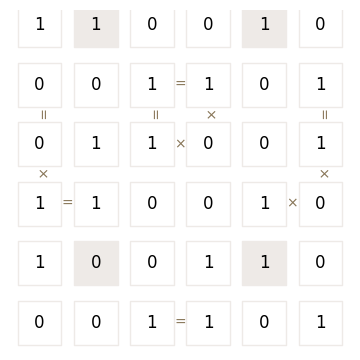

In [46]:
def solve_tango(n:int, m:int, like_pairs:dict, opp_pairs:dict, filled_squares:dict):

    model = pyo.ConcreteModel()

    # Ranges
    I = model.I = pyo.RangeSet(n)
    J = model.J = pyo.RangeSet(m)

    # Sets
    H = model.squares = pyo.Set(initialize=lambda model: [(i, j) for i in I for j in J])
    L = model.LikePairs = pyo.Set(initialize=like_pairs)
    O = model.OppositePairs = pyo.Set(initialize=opp_pairs)
    K = model.Filledsquares = pyo.Set(initialize=filled_squares.keys(), dimen=2)

    # Decision variables
    x = model.x = pyo.Var(I, J, within=pyo.Binary)
    
    # Parameters
    k = model.FilledValues = pyo.Param(K, initialize=filled_squares, within=pyo.Binary)

    # Objective function
    model.obj = pyo.Objective(expr=0, sense=pyo.maximize)

    # Constraints
    model.equal_moons_suns_per_row_constraints = pyo.Constraint(
        I,
        rule=lambda model, i: sum(x[i,j] for j in J) == m/2
    )

    model.equal_moons_suns_per_column_constraints = pyo.Constraint(
        J,
        rule=lambda model, j: sum(x[i,j] for i in I) == n/2
    )

    model.no_three_consecutive_moons_per_row_constraints = pyo.Constraint(
        I, pyo.RangeSet(m-2),
        rule=lambda model, i, j: x[i,j] + x[i,j+1] + x[i,j+2] <= 2
    )
    
    model.no_three_consecutive_suns_per_row_constraints = pyo.Constraint(
        I, pyo.RangeSet(m-2),
        rule=lambda model, i, j: x[i,j] + x[i,j+1] + x[i,j+2] >= 1
    )

    model.no_three_consecutive_moons_per_column_constraints = pyo.Constraint(
        pyo.RangeSet(n-2), J,
        rule=lambda model, i, j: x[i,j] + x[i+1,j] + x[i+2,j] <= 2
    )
    
    model.no_three_consecutive_suns_per_column_constraints = pyo.Constraint(
        pyo.RangeSet(n-2), J,
        rule=lambda model, i, j: x[i,j] + x[i+1,j] + x[i+2,j] >= 1
    )

    model.like_pairs_constraints = pyo.Constraint(
        L,
        rule=lambda model, i, j, r, s: x[i,j] - x[r,s] == 0
    )

    model.opposite_pairs_constraints = pyo.Constraint(
        O,
        rule=lambda model, i, j, r, s: x[i,j] + x[r,s] == 1
    )

    model.already_filled_squares_constraints = pyo.Constraint(
        K,
        rule=lambda model, i, j: x[i,j] == k[i,j]
    )

    # Solving model
    solver = pyo.SolverFactory("gurobi")
    result = solver.solve(model, tee=False)

    # display solution
    if str(result.Solver.status) == "ok":
        
        G = nx.grid_2d_graph(n,m)
        pos = {(i,j): (j, -i) for i, j in G.nodes()}
        
        plt.figure(figsize=(3.4, 3.4))
        
        nx.draw(
            G,
            pos= pos,
            with_labels= True,
            labels= {(i,j): int(x[i+1,j+1].value) for i, j in G.nodes()},
            node_size= 1000,
            node_color= ["#EEEAE7" if (i+1,j+1) in K else "white" for (i,j) in G.nodes()],
            node_shape="s",
            edgecolors="#EEEAE7",
            linewidths= 1,
            width= 0,
            edgelist = [
                ((i-1, j-1), (r-1,s-1)) for i,j,r,s in O] + [
                ((i-1, j-1), (r-1,s-1)) for i,j,r,s in L
            ]
        )
        nx.draw_networkx_edge_labels(
            G,
            pos= pos,
            edge_labels= {
                ((i-1, j-1), (r-1,s-1)): "×" for i,j,r,s in O} | {
                ((i-1, j-1), (r-1,s-1)): "=" for i,j,r,s in L
            },
            font_color="#887658"
        )
        plt.show()
    else:
        print('No valid solution was found!')


# dimensions of the Tango board
n = m = 6

# like (=) pairs, each element is ((i,j),(r,s))
like_pairs = [
    ((2, 3), (2, 4)),
    ((2, 1), (3, 1)),
    ((2, 3), (3, 3)),
    ((2, 6), (3, 6)),
    ((4, 1), (4, 2)),
    ((6, 3), (6, 4)),
]

# opposite (X) pairs
opp_pairs = [
    ((2, 4), (3, 4)),
    ((3, 1), (4, 1)),
    ((3, 3), (3, 4)),
    ((3, 6), (4, 6)),
    ((4, 5), (4, 6)),
]

# helper lists for the concrete instance (Tango #151)
# already filled squares: (i,j) -> kij
filled_squares = {
    (1, 2): 1,
    (1, 5): 1,
    (5, 2): 0,
    (5, 5): 1,
}

solve_tango(n, m, like_pairs, opp_pairs, filled_squares)

As expected, the image result matches the solution of Tango No. 151

:::{figure} ../assets/2-tango/solution.png
:label: tango-solution
:alt: Solution of Tango No. 151
:align: center
:width: 50%
Solution of Tango No. 151, March 7th, 2025. _Source: [LinkedIn](https://www.linkedin.com/games/tango/)_
:::

---

# References

- BELFIORE, Patrícia; FÁVERO, Luiz Paulo. **Pesquisa Operacional**: Para cursos de Administração, Contabilidade e Economia. Elsevier Editora Ltda., 2012.
- **Tango**. LinkedIn. Available at https://www.linkedin.com/games/tango/. Accessed March 7, 2025.